# L04 · Linear Regression and Gradient Descent

*Companion notebook for Lecture 4 — Linear Regression and Gradient Descent (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Fit a linear model $\hat y = \mathbf w^\top \mathbf x + b$ three ways: normal equations, gradient descent (GD), and stochastic gradient descent (SGD).
2. See how the learning rate $\eta$ and feature scaling control convergence.
3. Watch overfitting happen with polynomial features.
4. Apply the model to a clinical question and interpret it carefully.

Notation follows the course notation guide: $n$ samples, $d$ features, $\mathbf X\in\mathbb R^{n\times d}$ with samples as rows, loss $\mathcal L$, learning rate $\eta$.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from course_utils import seed_everything, plot_style

rng = seed_everything(0)
plot_style()

## 1. Dataset: diabetes progression

**Biological question.** Can measurements taken at a baseline visit predict how much a patient's diabetes progresses over the following year?

- **One sample** = one patient ($n = 442$).
- **Features** ($d = 10$): age, sex, body-mass index (BMI), mean blood pressure, and six blood-serum measurements (total cholesterol, LDL, HDL, total/HDL cholesterol ratio, log triglycerides, glucose).
- **Target** $y$: a quantitative measure of disease progression one year after baseline.

Source: Efron, Hastie, Johnstone & Tibshirani, *Least angle regression*, Annals of Statistics (2004). The data ship with scikit-learn (BSD-3-Clause), so no download is needed; the original data are publicly available from the authors.

In [2]:
data = load_diabetes(scaled=False)
X_raw, y = data.data, data.target
feature_names = ["age", "sex", "BMI", "blood pressure", "total cholesterol", "LDL", "HDL",
                 "TC/HDL", "log triglycerides", "glucose"]
bmi = X_raw[:, 2].copy()          # kept for the one-feature gradient-descent example below
drop = []                         # Try it yourself: e.g. drop = ["BMI"] or ["LDL"], then rerun the notebook
keep = [j for j, f in enumerate(feature_names) if f not in drop]
X_raw, feature_names = X_raw[:, keep], [feature_names[j] for j in keep]
n, d = X_raw.shape
print(f"n = {n} patients, d = {d} features; target range {y.min():.0f}–{y.max():.0f}")

n = 442 patients, d = 10 features; target range 25–346


## 2. Data exploration
Always look at the data first: feature scales, the target distribution, and correlations between features.

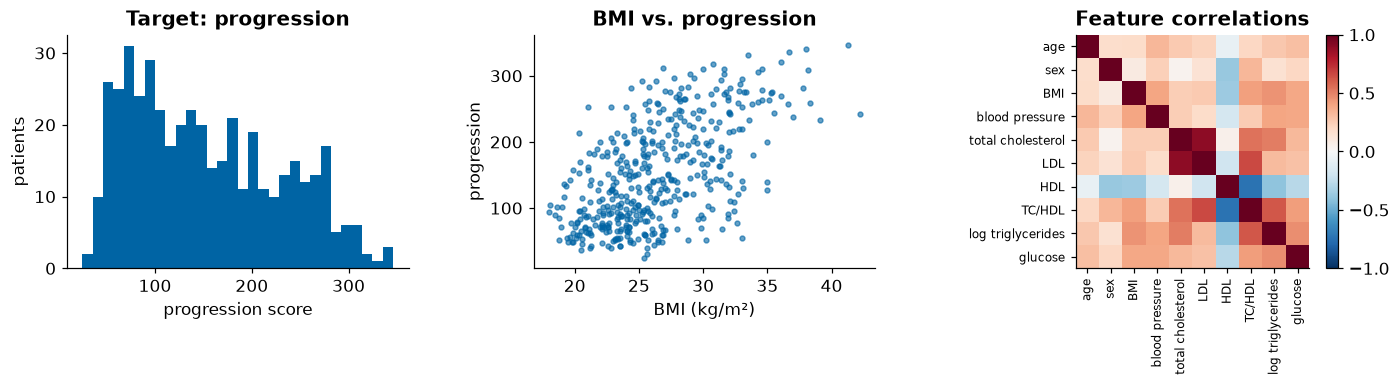

corr(total cholesterol, LDL) = 0.9


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(y, bins=30)
axes[0].set(title="Target: progression", xlabel="progression score", ylabel="patients")
axes[1].scatter(bmi, y, s=10, alpha=0.6)
axes[1].set(title="BMI vs. progression", xlabel="BMI (kg/m²)", ylabel="progression")
C = np.corrcoef(X_raw, rowvar=False)
im = axes[2].imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_xticks(range(d), feature_names, rotation=90, fontsize=8)
axes[2].set_yticks(range(d), feature_names, fontsize=8)
axes[2].set_title("Feature correlations")
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()
if {"total cholesterol", "LDL"} <= set(feature_names):
    print("corr(total cholesterol, LDL) =", round(C[feature_names.index("total cholesterol"), feature_names.index("LDL")], 2))

Notice the very different feature scales (age in years, BMI ~20–40, cholesterol in mg/dL) and the strong correlation between total cholesterol and LDL. Both will matter below.

## 3. Preprocessing: split first, then standardize
We hold out 20% of patients as a test set **before** computing any statistics, then standardize every feature with the *training* mean and standard deviation. Computing them on all data would leak test information into training (Lecture 6).

In [4]:
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(X_raw, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_tr_raw)
X_tr, X_te = scaler.transform(X_tr_raw), scaler.transform(X_te_raw)

def add_bias(X):
    """Prepend a column of ones: X̃ = [1, X]."""
    return np.c_[np.ones(len(X)), X]

Xt_tr, Xt_te = add_bias(X_tr), add_bias(X_te)
print(Xt_tr.shape, Xt_te.shape)

(353, 11) (89, 11)


## 4. Model 1 — normal equations
The least-squares solution satisfies $\tilde{\mathbf X}^\top\tilde{\mathbf X}\,\tilde{\mathbf w}^* = \tilde{\mathbf X}^\top \mathbf y$. We **solve** the system (never invert explicitly).

In [5]:
def mse(Xt, y, w):
    e = y - Xt @ w
    return e @ e / len(y)

w_ne = np.linalg.lstsq(Xt_tr, y_tr, rcond=None)[0]
print("bias b =", round(w_ne[0], 2))
print("training MSE =", round(mse(Xt_tr, y_tr, w_ne), 1))

# sanity check against scikit-learn
sk = LinearRegression().fit(X_tr, y_tr)
print("max |difference| vs scikit-learn:", np.abs(np.r_[sk.intercept_, sk.coef_] - w_ne).max())

bias b = 151.61
training MSE = 2734.8
max |difference| vs scikit-learn: 2.5579538487363607e-13


The residuals are orthogonal to every column of $\tilde{\mathbf X}$ — that is exactly what the normal equations say:

In [6]:
residual = y_tr - Xt_tr @ w_ne
print(np.round(Xt_tr.T @ residual, 8))

[-0. -0. -0. -0. -0. -0. -0.  0. -0. -0. -0.]


## 5. Model 2 — gradient descent
$\nabla_{\tilde{\mathbf w}}\mathcal L = \frac{2}{n}\tilde{\mathbf X}^\top(\tilde{\mathbf X}\tilde{\mathbf w}-\mathbf y)$, and GD repeats $\tilde{\mathbf w}\leftarrow\tilde{\mathbf w}-\eta\nabla\mathcal L$.

In [7]:
def gradient(Xt, y, w):
    return 2 / len(y) * Xt.T @ (Xt @ w - y)

def gradient_descent(Xt, y, eta, steps=200):
    w = np.zeros(Xt.shape[1])
    losses = [mse(Xt, y, w)]
    for _ in range(steps):
        w = w - eta * gradient(Xt, y, w)
        losses.append(mse(Xt, y, w))
    return w, np.array(losses)

H = 2 / len(y_tr) * Xt_tr.T @ Xt_tr           # Hessian of the MSE (constant)
lam_max = np.linalg.eigvalsh(H).max()
print(f"lambda_max = {lam_max:.2f}  ->  GD converges for eta < 2/lambda_max = {2 / lam_max:.3f}")

lambda_max = 8.29  ->  GD converges for eta < 2/lambda_max = 0.241


**The learning-rate slide's example.** The deck illustrates the learning rate on a one-feature problem: progression vs. BMI, with the
feature deliberately *un-centered*, $x = 0.6\,z + 1$ ($z$ = standardized BMI), so the loss bowl is tilted and elongated.
Same start $(b, w) = (-100, -80)$, 25 steps.

In [8]:
z_bmi = (bmi - bmi.mean()) / bmi.std()
Xt_bmi = add_bias(0.6 * z_bmi + 1.0)                    # all 442 patients, as on the slide
lam_max_bmi = np.linalg.eigvalsh(2 / n * Xt_bmi.T @ Xt_bmi).max()
print(f"un-centered BMI: lambda_max = {lam_max_bmi:.2f}  ->  edge of stability eta = 2/lambda_max = {2 / lam_max_bmi:.2f}")
for frac, label in [(0.05, "too small"), (0.5, "about right"), (1.03, "too large")]:
    w = np.array([-100.0, -80.0])
    for _ in range(25):
        w = w - frac * 2 / lam_max_bmi * gradient(Xt_bmi, y, w)
    print(f"eta = {frac:.2f} x 2/lambda_max ({label:11s}): MSE after 25 steps = {mse(Xt_bmi, y, w):,.0f}")

un-centered BMI: lambda_max = 4.39  ->  edge of stability eta = 2/lambda_max = 0.46
eta = 0.05 x 2/lambda_max (too small  ): MSE after 25 steps = 4,649
eta = 0.50 x 2/lambda_max (about right): MSE after 25 steps = 3,895
eta = 1.03 x 2/lambda_max (too large  ): MSE after 25 steps = 2,191,796


Back to all ten standardized features:

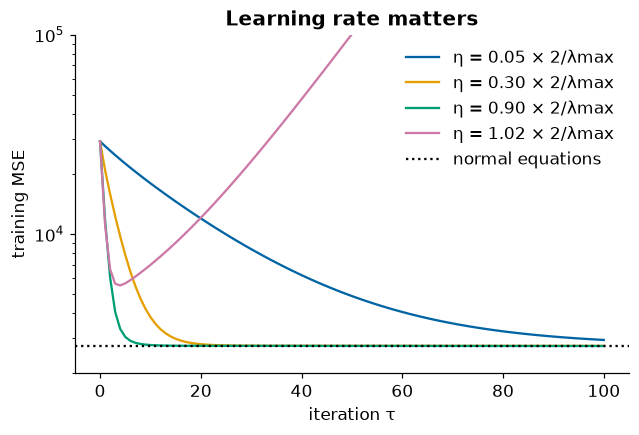

max |w_GD − w_NE| = 0.314106493277464


In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for frac in [0.05, 0.3, 0.9, 1.02]:
    eta = frac * 2 / lam_max
    _, losses = gradient_descent(Xt_tr, y_tr, eta, steps=100)
    ax.plot(losses, label=f"η = {frac:.2f} × 2/λmax")
ax.axhline(mse(Xt_tr, y_tr, w_ne), color="k", ls=":", label="normal equations")
ax.set(yscale="log", ylim=(2e3, 1e5), xlabel="iteration τ", ylabel="training MSE", title="Learning rate matters")
ax.legend(); plt.show()

w_gd, _ = gradient_descent(Xt_tr, y_tr, 0.5 * 2 / lam_max, steps=2000)
print("max |w_GD − w_NE| =", np.abs(w_gd - w_ne).max())

GD gets close but not exactly to the normal-equation solution after 2,000 steps. Even after standardization the Hessian's
condition number is in the hundreds, because several serum features are strongly correlated. The flat direction of
the bowl (a combination of correlated features) converges slowly. Ridge regression (Lecture 5) fixes this, too.

### Why scaling matters
Repeat GD on the **unstandardized** features. The Hessian becomes badly conditioned (condition number $\kappa=\lambda_{\max}/\lambda_{\min}$), so the largest stable step is tiny compared with what the flat directions need.

condition number: standardized 441.6, raw 5.19e+07


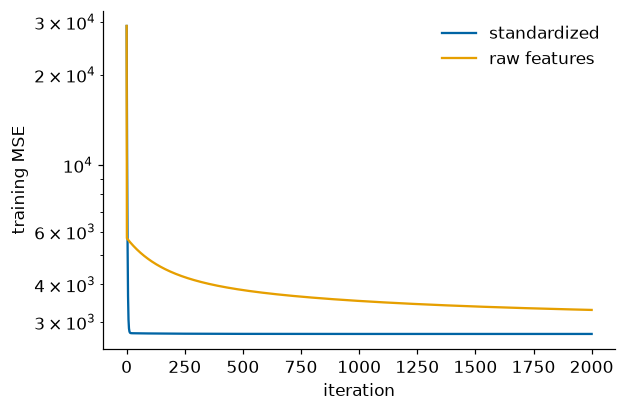

In [10]:
Xt_raw = add_bias(X_tr_raw)
H_raw = 2 / len(y_tr) * Xt_raw.T @ Xt_raw
ev = np.linalg.eigvalsh(H_raw)
print(f"condition number: standardized {np.linalg.cond(H):.1f}, raw {ev.max() / ev.min():.2e}")
_, loss_raw = gradient_descent(Xt_raw, y_tr, 0.5 * 2 / ev.max(), steps=2000)
_, loss_std = gradient_descent(Xt_tr, y_tr, 0.5 * 2 / lam_max, steps=2000)
plt.plot(loss_std, label="standardized"); plt.plot(loss_raw, label="raw features")
plt.yscale("log"); plt.xlabel("iteration"); plt.ylabel("training MSE"); plt.legend(); plt.show()

## 6. Model 3 — stochastic gradient descent
SGD uses one sample per update: $\tilde{\mathbf w}\leftarrow\tilde{\mathbf w}-\eta\, 2(\hat y_i-y_i)\tilde{\mathbf x}_i$. One **epoch** is one pass over the shuffled training set.

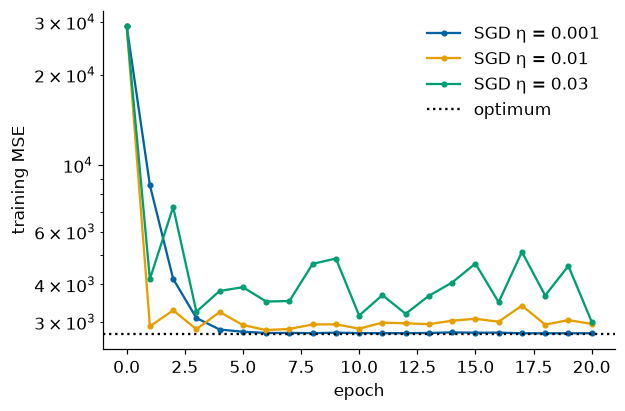

In [11]:
def sgd(Xt, y, eta, epochs=20, seed=0):
    r = np.random.default_rng(seed)
    w = np.zeros(Xt.shape[1])
    losses = [mse(Xt, y, w)]
    for epoch in range(epochs):
        for i in r.permutation(len(y)):
            w -= eta * 2 * (Xt[i] @ w - y[i]) * Xt[i]
        losses.append(mse(Xt, y, w))
    return w, np.array(losses)

for eta in [0.001, 0.01, 0.03]:
    w_sgd, losses = sgd(Xt_tr, y_tr, eta)
    plt.plot(losses, "o-", ms=3, label=f"SGD η = {eta}")
plt.axhline(mse(Xt_tr, y_tr, w_ne), color="k", ls=":", label="optimum")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("training MSE"); plt.legend(); plt.show()

With a fixed step size SGD hovers near — not exactly at — the optimum. Decaying $\eta$ over epochs removes that noise floor (Lecture 8).

## 7. Overfitting with polynomial features
A one-dimensional toy dose–response curve (synthetic data: $y=\sin 2\pi x+\varepsilon$). Least squares with features $[1, x, \dots, x^p]$.

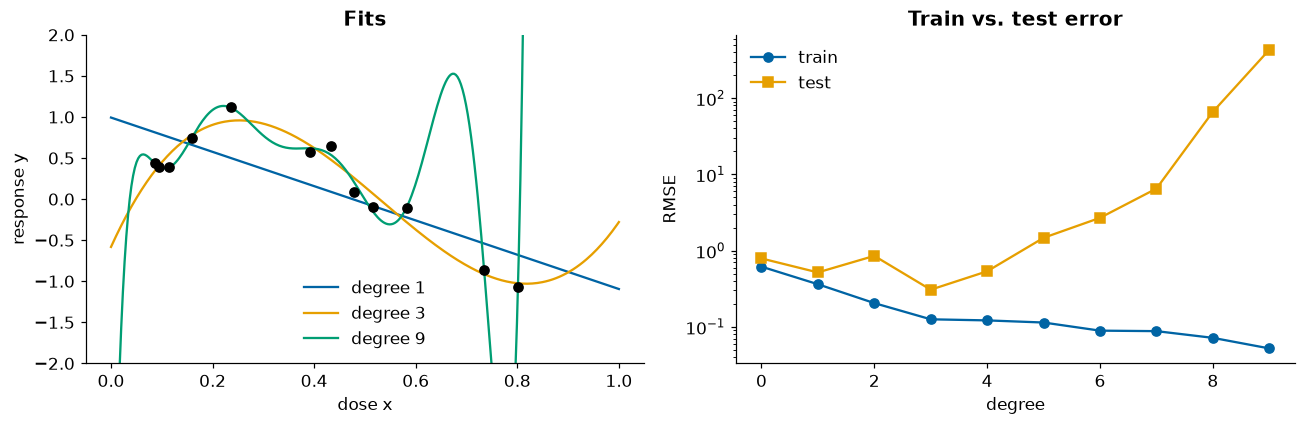

In [12]:
def poly_data(n, seed):
    r = np.random.default_rng(seed)
    x = np.sort(r.uniform(0, 1, n))
    return x, np.sin(2 * np.pi * x) + r.normal(0, 0.25, n)

x_small, y_small = poly_data(12, seed=3)
x_test, y_test = poly_data(1000, seed=99)
Phi = lambda x, p: np.vander(x, p + 1, increasing=True)

degrees = range(10)
train_rmse, test_rmse = [], []
for p in degrees:
    w = np.linalg.lstsq(Phi(x_small, p), y_small, rcond=None)[0]
    train_rmse.append(np.sqrt(np.mean((Phi(x_small, p) @ w - y_small) ** 2)))
    test_rmse.append(np.sqrt(np.mean((Phi(x_test, p) @ w - y_test) ** 2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xs = np.linspace(0, 1, 300)
for p in [1, 3, 9]:
    w = np.linalg.lstsq(Phi(x_small, p), y_small, rcond=None)[0]
    axes[0].plot(xs, Phi(xs, p) @ w, label=f"degree {p}")
axes[0].scatter(x_small, y_small, color="k", zorder=3)
axes[0].set(ylim=(-2, 2), title="Fits", xlabel="dose x", ylabel="response y"); axes[0].legend()
axes[1].plot(degrees, train_rmse, "o-", label="train"); axes[1].plot(degrees, test_rmse, "s-", label="test")
axes[1].set(yscale="log", xlabel="degree", ylabel="RMSE", title="Train vs. test error"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Application: evaluation on held-out patients
Compare against two baselines: predicting the training mean, and kNN regression from Lecture 2.

predict training mean    test RMSE =   71.7   R² = -0.001
kNN (k = 15)             test RMSE =   59.0   R² =  0.321
linear regression        test RMSE =   58.5   R² =  0.332


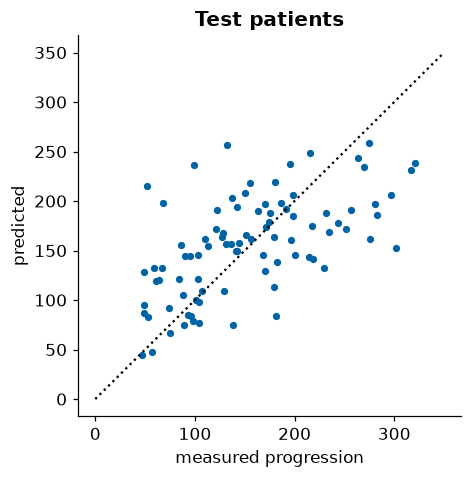

In [13]:
models = {
    "predict training mean": np.full_like(y_te, y_tr.mean()),
    "kNN (k = 15)": KNeighborsRegressor(n_neighbors=15).fit(X_tr, y_tr).predict(X_te),
    "linear regression": Xt_te @ w_ne,
}
for name, pred in models.items():
    print(f"{name:24s} test RMSE = {mean_squared_error(y_te, pred) ** 0.5:6.1f}   R² = {r2_score(y_te, pred):6.3f}")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(y_te, Xt_te @ w_ne, s=14)
plt.plot([0, 350], [0, 350], "k:"); plt.xlabel("measured progression"); plt.ylabel("predicted")
plt.title("Test patients"); plt.show()

The mean baseline's $R^2$ is slightly below 0 because the training mean differs from the test mean. One random split of 89 patients gives a noisy estimate. Lecture 6 shows how to put an uncertainty on it (cross-validation, bootstrap).

## 9. Biological interpretation
Standardized coefficients: change in predicted progression per one standard deviation of a feature, **holding the others fixed**.

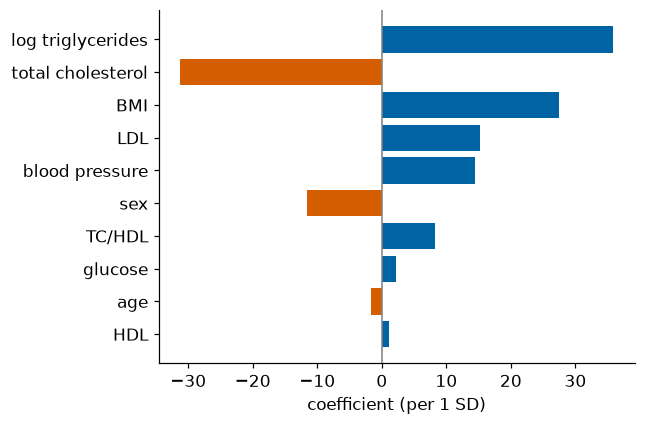

log triglycerides     35.8   95% bootstrap interval [  17.4,   53.1]
total cholesterol    -31.2   95% bootstrap interval [ -67.1,   13.1]
BMI                   27.5   95% bootstrap interval [  20.4,   34.0]
LDL                   15.3   95% bootstrap interval [ -25.1,   42.9]
blood pressure        14.4   95% bootstrap interval [   7.5,   21.6]


In [14]:
coef = w_ne[1:]
order = np.argsort(np.abs(coef))
plt.figure(figsize=(6, 4))
plt.barh(np.array(feature_names)[order], coef[order], color=["#0064A4" if c > 0 else "#D55E00" for c in coef[order]])
plt.axvline(0, color="gray", lw=1); plt.xlabel("coefficient (per 1 SD)"); plt.tight_layout(); plt.show()

# How stable are the coefficients? Refit on bootstrap resamples of the training set.
boot = []
for b in range(200):
    idx = rng.integers(0, len(y_tr), len(y_tr))
    boot.append(np.linalg.lstsq(Xt_tr[idx], y_tr[idx], rcond=None)[0][1:])
boot = np.array(boot)
for j in np.argsort(-np.abs(coef))[:5]:
    lo, hi = np.percentile(boot[:, j], [2.5, 97.5])
    print(f"{feature_names[j]:18s} {coef[j]:7.1f}   95% bootstrap interval [{lo:6.1f}, {hi:6.1f}]")

**Interpretation caveats.**
- BMI and log triglycerides have large, stable positive coefficients.
- Total cholesterol and LDL are strongly correlated, so their individual coefficients are large, opposite in sign, and unstable across resamples. The model can trade one for the other with little change in fit. Ridge regression (Lecture 5) stabilizes them.
- Coefficients describe associations in this cohort. "Holding the others fixed" is not an intervention, and none of this is causal.

## 10. Try it yourself
1. Double η until GD diverges. What value? Compare with 2/λ_max. (Add values such as `1.1, 2.0` to the list of `frac` in the learning-rate cell, or to the un-centered-BMI cell.)
2. Skip standardization. How many more GD steps are needed? (Raise `steps` in the "Why scaling matters" cell, e.g. to 20,000, and compare with the standardized curve.)
3. Drop BMI. How much does test R² change? What about dropping LDL? (Set `drop = ["BMI"]` in the dataset cell and rerun the notebook.)
4. Change `random_state` in the train/test split. How much does test RMSE vary? (Preview of Lecture 6.)
5. *(CS284A)* Show that the SGD update is an unbiased estimate of the GD update when $i$ is sampled uniformly.